In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, PolynomialFeatures,OneHotEncoder,StandardScaler,RobustScaler
from sklearn.impute import SimpleImputer

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [29]:
df=pd.read_csv("/content/Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [31]:
df.isna().sum()

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4662.000000,4888.000000,4637.000000,4888.000000,4843.000000,4862.000000,4748.000000,4888.000000,4888.000000,4888.000000,4822.000000,4655.000000
mean,202443.500000,0.188216,37.622265,1.654255,15.490835,2.905074,3.708445,3.581037,3.236521,0.290917,3.078151,0.620295,1.187267,23619.853491
std,1411.188388,0.390925,9.316387,0.916583,8.519643,0.724891,1.002509,0.798009,1.849019,0.454232,1.365792,0.485363,0.857861,5380.698361
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,201221.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,20346.000000
50%,202443.500000,0.000000,36.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,3.000000,1.000000,1.000000,22347.000000
75%,203665.250000,0.000000,44.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.000000,1.000000,4.000000,1.000000,2.000000,25571.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,5.000000,1.000000,3.000000,98678.000000


In [34]:
df.describe(include="object").columns


Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')

In [35]:
dff=df.describe(include="object").columns
for i in dff:
  print(i)
  print(df[i].unique())

TypeofContact
['Self Enquiry' 'Company Invited' nan]
Occupation
['Salaried' 'Free Lancer' 'Small Business' 'Large Business']
Gender
['Female' 'Male' 'Fe Male']
ProductPitched
['Deluxe' 'Basic' 'Standard' 'Super Deluxe' 'King']
MaritalStatus
['Single' 'Divorced' 'Married' 'Unmarried']
Designation
['Manager' 'Executive' 'Senior Manager' 'AVP' 'VP']


In [36]:
df["Gender"]=df["Gender"].replace("Fe Male","Female")

In [37]:
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried')

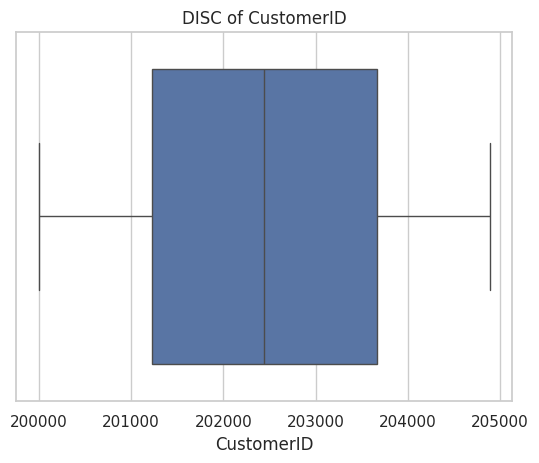

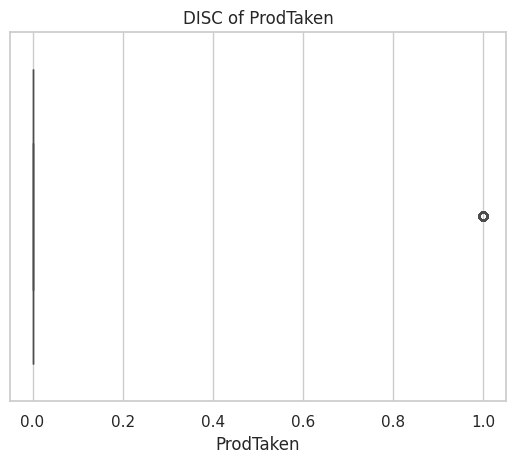

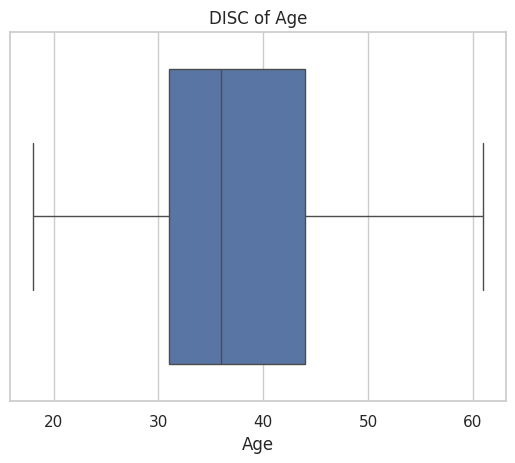

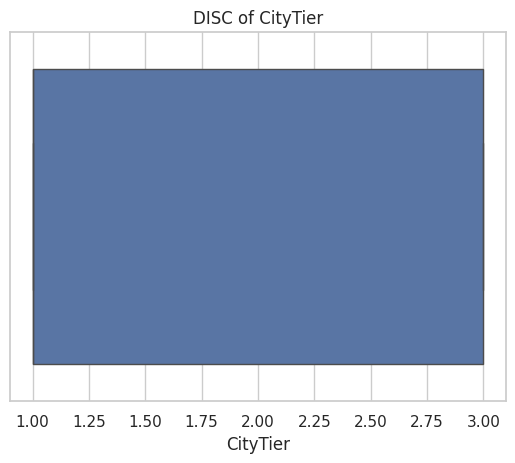

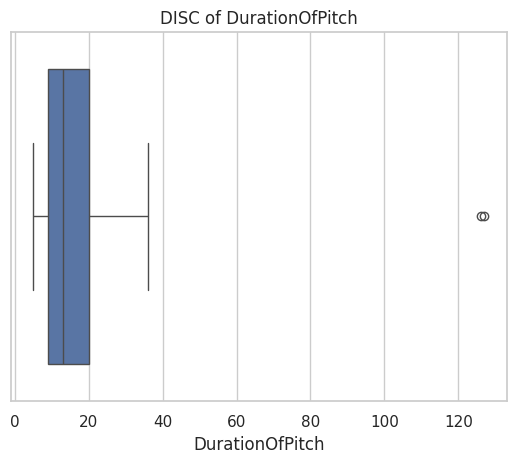

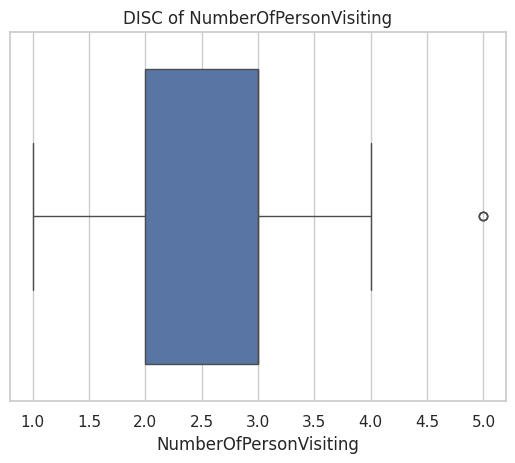

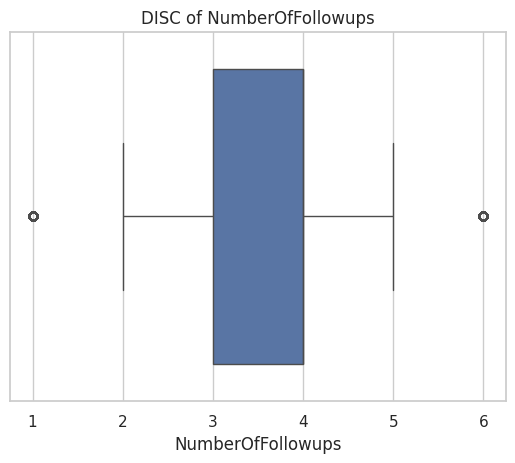

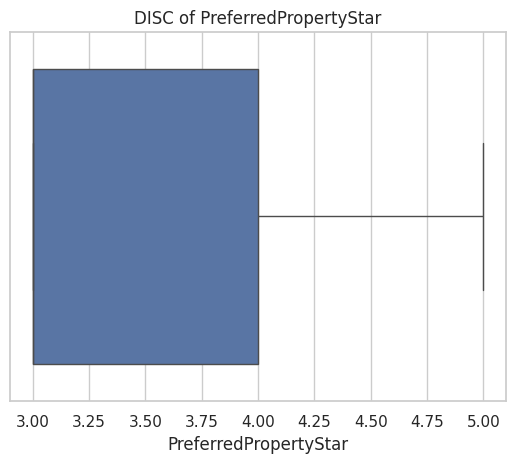

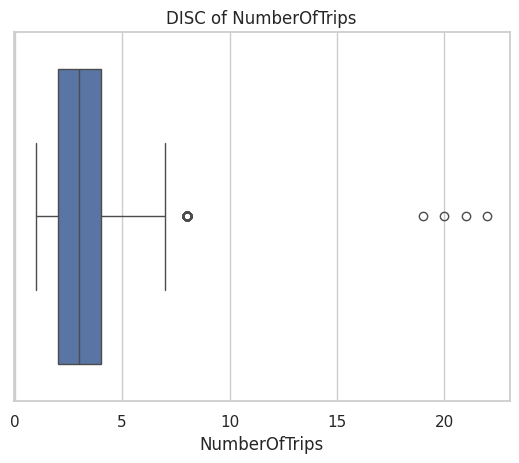

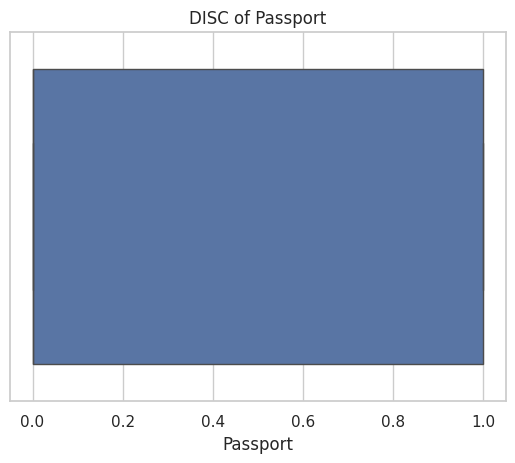

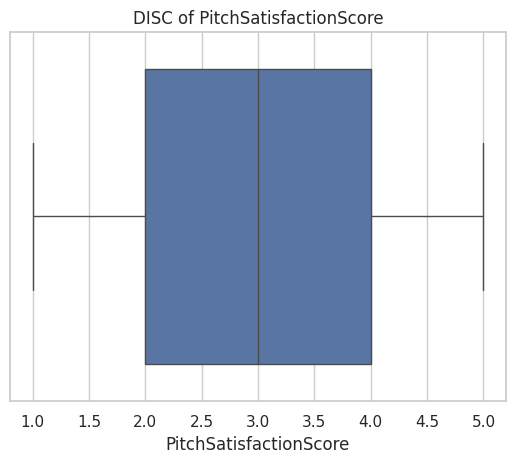

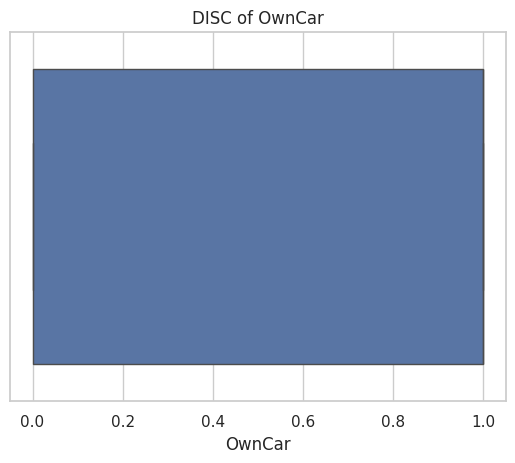

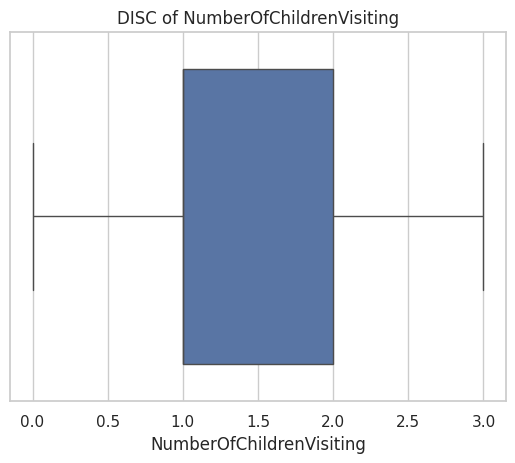

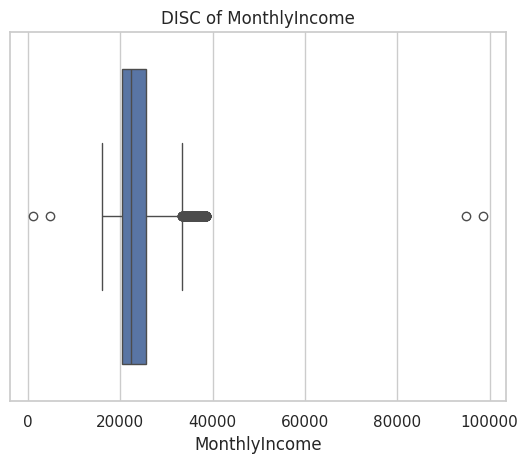

In [38]:
for col in df.select_dtypes(include="number").columns:
  sns.boxplot(data=df,x=col)
  plt.title(f"DISC of {col}")
  plt.show()

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

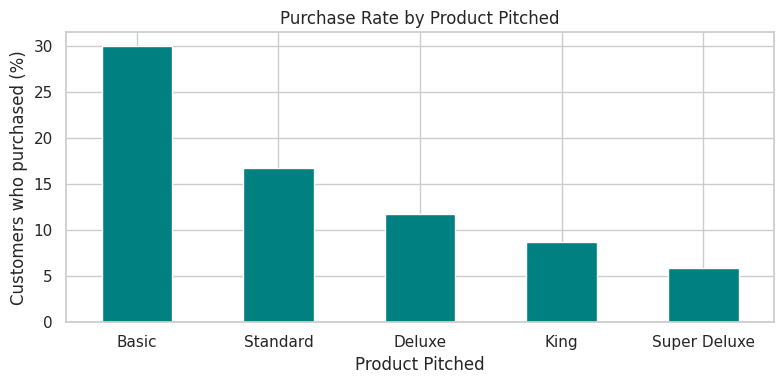

In [40]:
# معدل شراء المنتج حسب المنتج المعروض — أهم رسم لمعرفة أي منتج عُرض على العملاء الأكثر شراءً:
purchase_rate = (
    df.groupby("ProductPitched", observed=True)["ProdTaken"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

ax = purchase_rate.plot(kind="bar", color="teal", figsize=(8, 4))
ax.set(title="Purchase Rate by Product Pitched",
       xlabel="Product Pitched", ylabel="Customers who purchased (%)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

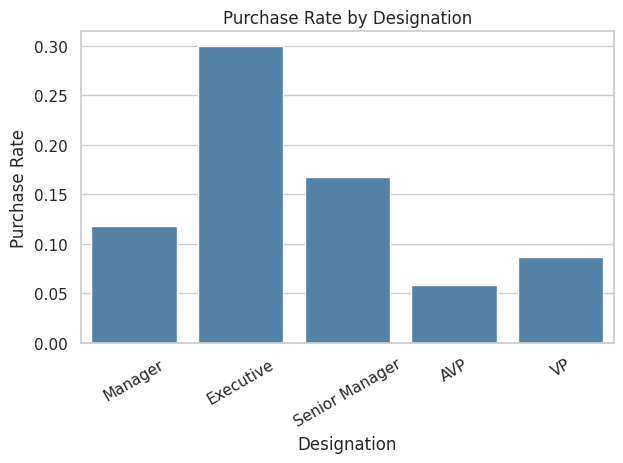

In [41]:
# معدل الشراء حسب المسمّى الوظيفي
sns.barplot(data=df, x="Designation", y="ProdTaken",
            estimator="mean", errorbar=None, color="steelblue")
plt.title("Purchase Rate by Designation")
plt.xlabel("Designation")
plt.ylabel("Purchase Rate")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

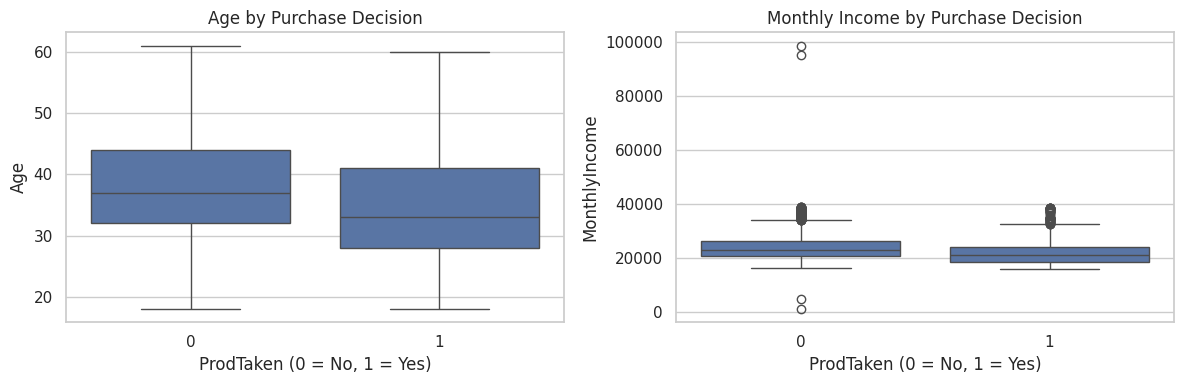

In [42]:
# 3) العمر والدخل حسب قرار الشراء:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="ProdTaken", y="Age", ax=axes[0])
axes[0].set_title("Age by Purchase Decision")
axes[0].set_xlabel("ProdTaken (0 = No, 1 = Yes)")

sns.boxplot(data=df, x="ProdTaken", y="MonthlyIncome", ax=axes[1])
axes[1].set_title("Monthly Income by Purchase Decision")
axes[1].set_xlabel("ProdTaken (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()

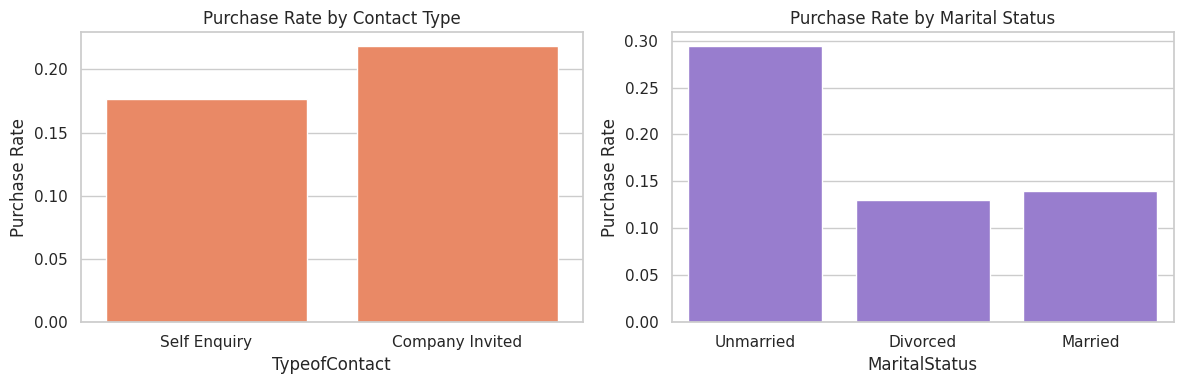

In [43]:
# 4) معدل الشراء حسب طريقة التواصل والحالة الاجتماعية:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="TypeofContact", y="ProdTaken",
            estimator="mean", errorbar=None, ax=axes[0], color="coral")
axes[0].set_title("Purchase Rate by Contact Type")
axes[0].set_ylabel("Purchase Rate")

sns.barplot(data=df, x="MaritalStatus", y="ProdTaken",
            estimator="mean", errorbar=None, ax=axes[1], color="mediumpurple")
axes[1].set_title("Purchase Rate by Marital Status")
axes[1].set_ylabel("Purchase Rate")

plt.tight_layout()
plt.show()

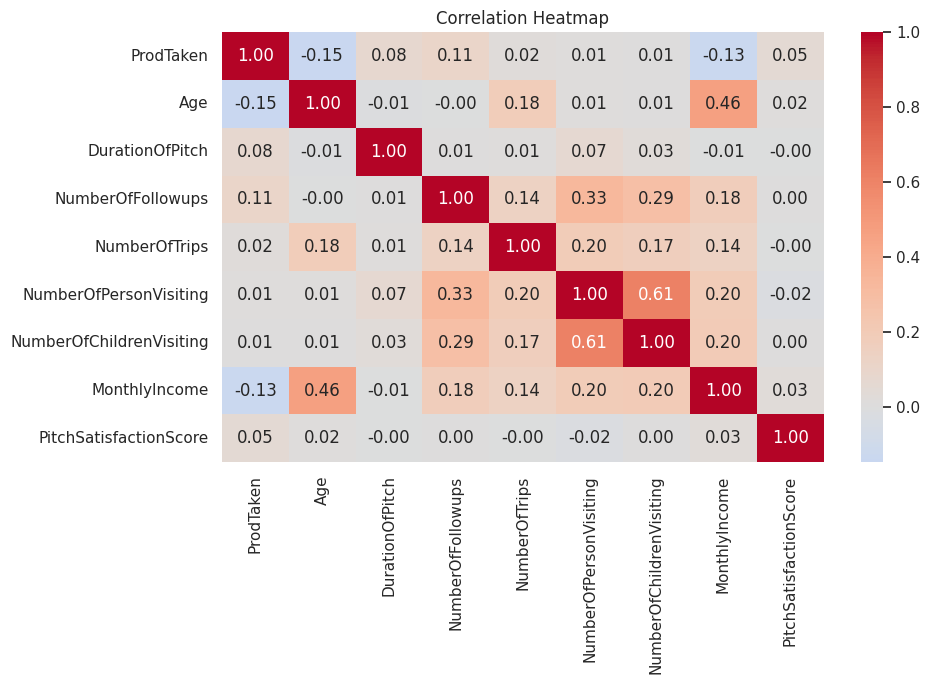

In [44]:
# 5) خريطة ارتباط الأعمدة الرقمية بقرار الشراء:
numeric_cols = [
    "ProdTaken", "Age", "DurationOfPitch", "NumberOfFollowups",
    "NumberOfTrips", "NumberOfPersonVisiting",
    "NumberOfChildrenVisiting", "MonthlyIncome",
    "PitchSatisfactionScore"
]

corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [45]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['TypeofContact'] = df['TypeofContact'].fillna(df['TypeofContact'].mode()[0])
df['DurationOfPitch'] = df['DurationOfPitch'].fillna(df['DurationOfPitch'].median())
df['NumberOfFollowups'] = df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0])
df['PreferredPropertyStar'] = df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mode()[0])
df['NumberOfTrips'] = df['NumberOfTrips'].fillna(df['NumberOfTrips'].median())
df['NumberOfChildrenVisiting'] = df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mode()[0])

In [46]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

In [47]:
df.isna().sum()

,0
CustomerID,0
ProdTaken,0
Age,0
TypeofContact,0
CityTier,0
DurationOfPitch,0
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,0


In [48]:
df['TotalVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.drop(['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], inplace= True, axis = 1)

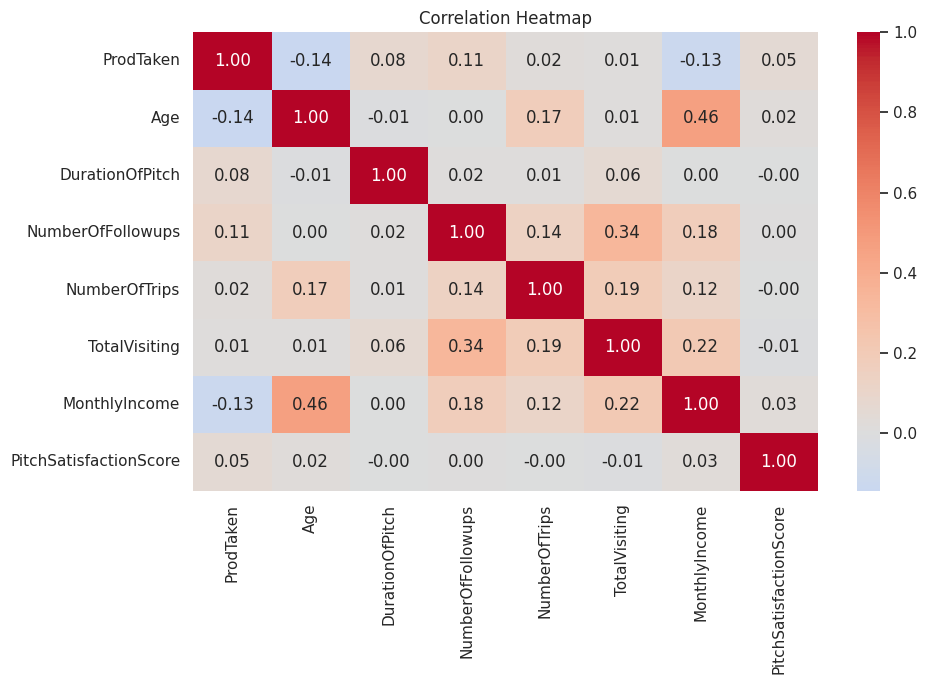

In [49]:
numeric_cols = [
    "ProdTaken", "Age", "DurationOfPitch", "NumberOfFollowups",
    "NumberOfTrips", "TotalVisiting",
     "MonthlyIncome",
    "PitchSatisfactionScore"
]

corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [50]:
df.drop('CustomerID', inplace=True, axis = 1)

In [51]:
X = df.drop(['ProdTaken'], axis = 1)
y = df['ProdTaken']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [58]:
encode_col=df.describe(include="object").columns
num_col=df.select_dtypes(include="number").columns

encode_pip=Pipeline([
                    ("encode",OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)),
                    ("scale",RobustScaler())
])

num_pip=Pipeline([
                  ("scale",RobustScaler())
])

preprocessor=ColumnTransformer([
                                ("encode",encode_pip,encode_col),
                                ("num",num_pip,num_col)

], verbose_feature_names_out=True).set_output(transform='pandas')




31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


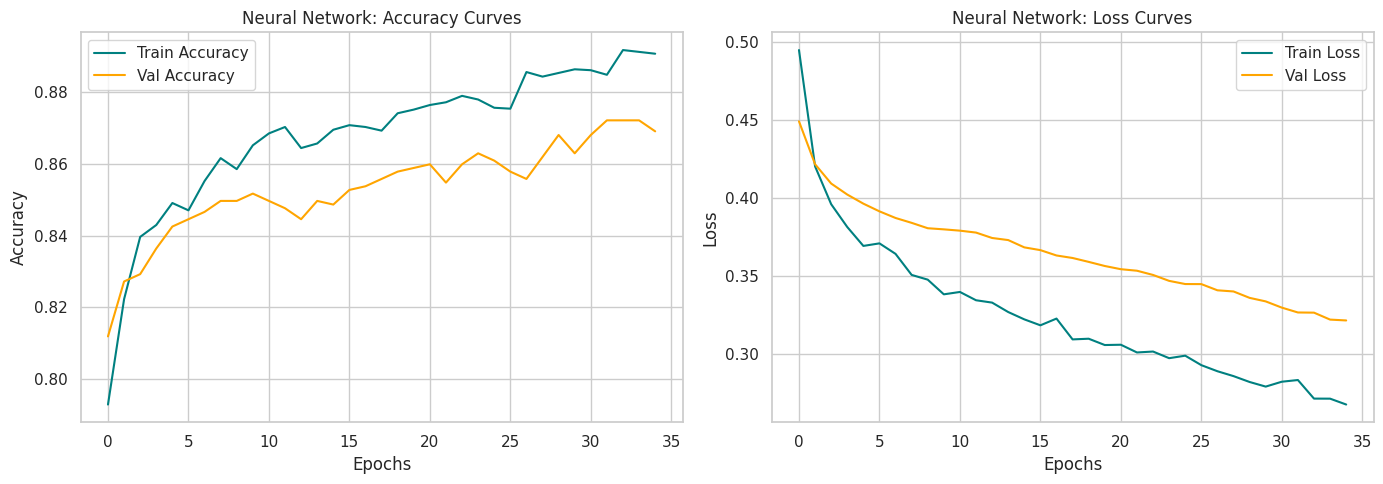

=== Performance Comparison Matrix ===
               Accuracy  Precision  Recall  F1-Score
Random Forest    0.9376     0.9767  0.6848    0.8051
Decision Tree    0.9141     0.8012  0.7228    0.7600
SVM              0.8609     0.8243  0.3315    0.4729
Deep Learning    0.8691     0.7414  0.4674    0.5733


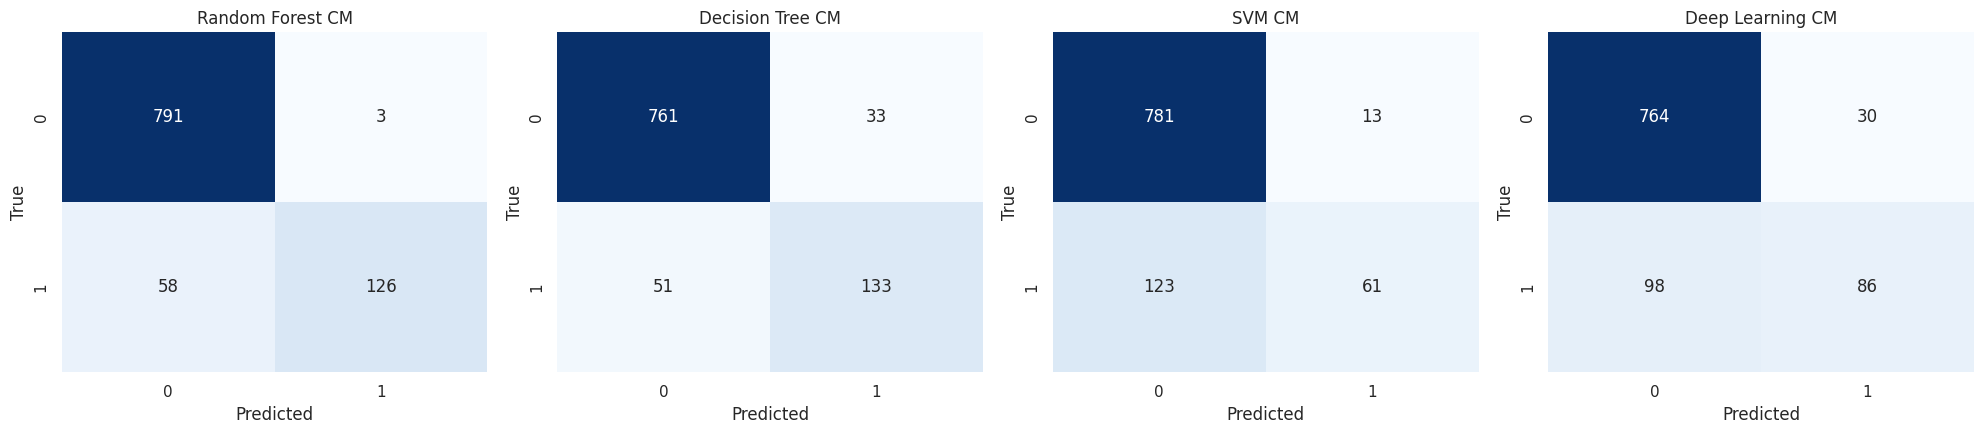

In [61]:
# 1) Preprocess the data
encode_col = X_train.select_dtypes(include="object").columns
num_col = X_train.select_dtypes(include="number").columns

encode_pip = Pipeline([
    ("encode", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
    ("scale", RobustScaler())
])

num_pip = Pipeline([
    ("scale", RobustScaler())
])

preprocessor = ColumnTransformer([
    ("encode", encode_pip, encode_col),
    ("num", num_pip, num_col)
], verbose_feature_names_out=True).set_output(transform='pandas')

X_train_pro = preprocessor.fit_transform(X_train)
X_test_pro = preprocessor.transform(X_test)

# 2) Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

ml_models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = {}
y_preds = {}

for name, model in ml_models.items():
    model.fit(X_train_pro, y_train)
    preds = model.predict(X_test_pro)
    y_preds[name] = preds
    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1-Score": f1_score(y_test, preds, zero_division=0)
    }

# 3) Deep Learning Model (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)

# Build the Neural Network
dl_model = models.Sequential([
    layers.Input(shape=(X_train_pro.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = dl_model.fit(
    X_train_pro, y_train,
    validation_data=(X_test_pro, y_test),
    epochs=35,
    batch_size=32,
    verbose=0
)

# Predict and evaluate Deep Learning model
dl_probs = dl_model.predict(X_test_pro).flatten()
dl_preds = (dl_probs >= 0.5).astype(int)
y_preds["Deep Learning"] = dl_preds

results["Deep Learning"] = {
    "Accuracy": accuracy_score(y_test, dl_preds),
    "Precision": precision_score(y_test, dl_preds, zero_division=0),
    "Recall": recall_score(y_test, dl_preds, zero_division=0),
    "F1-Score": f1_score(y_test, dl_preds, zero_division=0)
}

# Plot Loss and Accuracy Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='teal')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Neural Network: Accuracy Curves')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='teal')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Neural Network: Loss Curves')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# 4) Evaluation & Comparison
results_df = pd.DataFrame(results).T
print("=== Performance Comparison Matrix ===")
print(results_df.round(4))

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for i, (name, preds) in enumerate(y_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"{name} CM")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

plt.tight_layout()
plt.show()

In [62]:
counts = df["ProdTaken"].value_counts()
percentages = df["ProdTaken"].value_counts(normalize=True) * 100

print(counts)
print(percentages.round(2))

ProdTaken
0    3968
1     920
Name: count, dtype: int64
ProdTaken
0    81.18
1    18.82
Name: proportion, dtype: float64


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix


xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       794
           1       0.87      0.57      0.69       184

    accuracy                           0.90       978
   macro avg       0.89      0.78      0.82       978
weighted avg       0.90      0.90      0.89       978

[[778  16]
 [ 79 105]]


In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# توقع الفئات واحتمال الفئة الإيجابية
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.9028629856850716
Precision: 0.8677685950413223
Recall   : 0.5706521739130435
F1-score : 0.6885245901639344
ROC-AUC  : 0.9177253312890155

Classification report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       794
           1       0.87      0.57      0.69       184

    accuracy                           0.90       978
   macro avg       0.89      0.78      0.82       978
weighted avg       0.90      0.90      0.89       978



In [66]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [3, 5, 7],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 300, 'classifier__subsample': 1.0}
Best CV F1: 0.7950113279892826
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       794
           1       0.92      0.76      0.83       184

    accuracy                           0.94       978
   macro avg       0.93      0.87      0.90       978
weighted avg       0.94      0.94      0.94       978

[[782  12]
 [ 45 139]]


In [67]:
grid_search.best_score_

np.float64(0.7950113279892826)

In [68]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# نسبة غير المشترين إلى المشترين داخل بيانات التدريب
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ))
])

param_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [5, 7],
    "classifier__scale_pos_weight": [1, scale_pos_weight]
}

grid_search = GridSearchCV(
    xgb_model,
    param_grid,
    scoring="recall",  # يركز على اكتشاف أكبر عدد من المشترين
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("أفضل الإعدادات:", grid_search.best_params_)
print("أفضل Recall أثناء التحقق:", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
أفضل الإعدادات: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': np.float64(4.3125)}
أفضل Recall أثناء التحقق: 0.7840044125758412


In [75]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# وزن الفئة الإيجابية حسب توزيع بيانات التدريب
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = neg / pos

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

param_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [5, 7],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__scale_pos_weight": [1, class_weight]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("أفضل الإعدادات:", grid_search.best_params_)
print("أفضل accuracy أثناء التحقق:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 64 candidates, totalling 320 fits
أفضل الإعدادات: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 300, 'classifier__scale_pos_weight': np.float64(4.3125), 'classifier__subsample': 1.0}
أفضل accuracy أثناء التحقق: 0.9342710997442454
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       794
           1       0.89      0.80      0.84       184

    accuracy                           0.94       978
   macro avg       0.92      0.89      0.90       978
weighted avg       0.94      0.94      0.94       978

[[775  19]
 [ 36 148]]


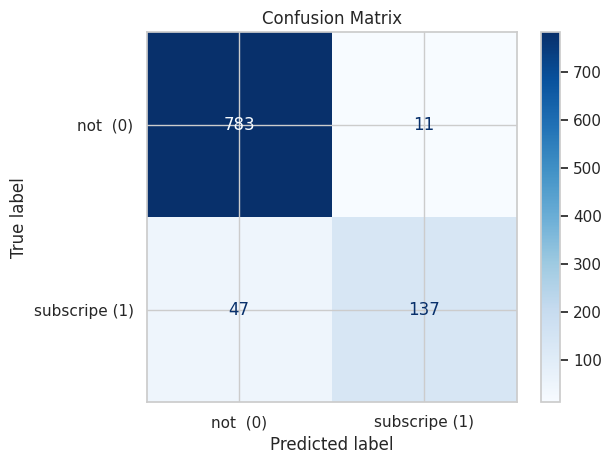

In [80]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["not  (0)", "subscripe (1)"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [76]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# وزن الفئة الإيجابية حسب توزيع بيانات التدريب
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = neg / pos

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

param_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [5, 7],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__scale_pos_weight": [1, class_weight]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("أفضل الإعدادات:", grid_search.best_params_)
print("أفضل f1 أثناء التحقق:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 64 candidates, totalling 320 fits
أفضل الإعدادات: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 300, 'classifier__scale_pos_weight': np.float64(4.3125), 'classifier__subsample': 1.0}
أفضل f1 أثناء التحقق: 0.8169207378041993
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       794
           1       0.89      0.80      0.84       184

    accuracy                           0.94       978
   macro avg       0.92      0.89      0.90       978
weighted avg       0.94      0.94      0.94       978

[[775  19]
 [ 36 148]]


In [77]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# وزن الفئة الإيجابية حسب توزيع بيانات التدريب
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = neg / pos

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

param_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [5, 7],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__scale_pos_weight": [1, class_weight]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("أفضل الإعدادات:", grid_search.best_params_)
print("أفضل Recall أثناء التحقق:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 64 candidates, totalling 320 fits
أفضل الإعدادات: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': np.float64(4.3125), 'classifier__subsample': 0.8}
أفضل Recall أثناء التحقق: 0.7853833425261996
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       794
           1       0.86      0.79      0.83       184

    accuracy                           0.94       978
   macro avg       0.91      0.88      0.89       978
weighted avg       0.94      0.94      0.94       978

[[771  23]
 [ 38 146]]


In [78]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# وزن الفئة الإيجابية حسب توزيع بيانات التدريب
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = neg / pos

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

param_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [5, 7],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__scale_pos_weight": [1, class_weight]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="precision",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("أفضل الإعدادات:", grid_search.best_params_)
print("أفضل precision أثناء التحقق:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 64 candidates, totalling 320 fits
أفضل الإعدادات: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': 1, 'classifier__subsample': 1.0}
أفضل precision أثناء التحقق: 0.903119413919414
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       794
           1       0.93      0.74      0.83       184

    accuracy                           0.94       978
   macro avg       0.93      0.87      0.89       978
weighted avg       0.94      0.94      0.94       978

[[783  11]
 [ 47 137]]


In [84]:
import pandas as pd
from sklearn.metrics import accuracy_score

# أدخل بيانات عميل جديد بنفس أسماء أعمدة X_train
new_data = {}

for col in X_train.columns:
    value = input(f"أدخل قيمة {col}: ")

    # تحويل المدخلات الرقمية إلى أرقام
    if pd.api.types.is_numeric_dtype(X_train[col]):
        value = pd.to_numeric(value)

    new_data[col] = [value]

customer = pd.DataFrame(new_data)

# توقع الموديل
prediction = best_model.predict(customer)[0]

print("\nتوقع الموديل:")
print("سيأخذ المنتج" if prediction == 1 else "لن يأخذ المنتج")

# أدخل النتيجة الحقيقية بعد معرفتها
actual = int(input("\nأدخل النتيجة الحقيقية (1 اشترى، 0 لم يشترِ): "))

# دقة حالة واحدة
case_accuracy = accuracy_score([actual], [prediction])
print(f"دقة هذه الحالة: {case_accuracy * 100:.0f}%")

أدخل قيمة Age: 32
أدخل قيمة TypeofContact: Self Enquiry
أدخل قيمة CityTier: 2
أدخل قيمة DurationOfPitch: 12
أدخل قيمة Occupation: Salaried
أدخل قيمة Gender: Male
أدخل قيمة NumberOfFollowups: 2
أدخل قيمة ProductPitched: Basic
أدخل قيمة PreferredPropertyStar: 4
أدخل قيمة MaritalStatus: 2
أدخل قيمة NumberOfTrips: 3
أدخل قيمة Passport: 1
أدخل قيمة PitchSatisfactionScore: 5
أدخل قيمة OwnCar: 1
أدخل قيمة Designation: Manager
أدخل قيمة MonthlyIncome: 25000
أدخل قيمة TotalVisiting: 5


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



توقع الموديل:
لن يأخذ المنتج

أدخل النتيجة الحقيقية (1 اشترى، 0 لم يشترِ): 1
دقة هذه الحالة: 0%


In [88]:
import pandas as pd

# Create a dictionary to hold the customer's feature inputs
customer_data = {}

print("Please provide the details for the new customer:\n")
for col in X_train.columns:
    value = input(f"{col}: ")

    # Automatically convert to float/int if the training feature is numeric
    if pd.api.types.is_numeric_dtype(X_train[col]):
        customer_data[col] = [float(value)]
    else:
        customer_data[col] = [value]

customer = pd.DataFrame(customer_data)

# Perform prediction using the best model pipeline
prediction = best_model.predict(customer)[0]
probability = best_model.predict_proba(customer)[0, 1]

print("\nالتوقع:", "سيأخذ المنتج" if prediction == 1 else "لن يأخذ المنتج")
print(f"احتمال أخذ المنتج: {probability:.1%}")

Please provide the details for the new customer:




KeyboardInterrupt



In [89]:
!pip install -q gradio
import gradio as gr
import pandas as pd

def predict_customer(age, typeof_contact, city_tier, duration_pitch, occupation, gender,
                     number_of_followups, product_pitched, preferred_property_star,
                     marital_status, number_of_trips, passport, pitch_satisfaction,
                     own_car, designation, monthly_income, total_visiting):

    # Construct a DataFrame matching the model's exact features
    input_data = pd.DataFrame([{
        "Age": age,
        "TypeofContact": typeof_contact,
        "CityTier": city_tier,
        "DurationOfPitch": duration_pitch,
        "Occupation": occupation,
        "Gender": gender,
        "NumberOfFollowups": number_of_followups,
        "ProductPitched": product_pitched,
        "PreferredPropertyStar": preferred_property_star,
        "MaritalStatus": marital_status,
        "NumberOfTrips": number_of_trips,
        "Passport": 1 if passport == "Yes" else 0,
        "PitchSatisfactionScore": pitch_satisfaction,
        "OwnCar": 1 if own_car == "Yes" else 0,
        "Designation": designation,
        "MonthlyIncome": monthly_income,
        "TotalVisiting": total_visiting
    }])

    # Predict class and probability
    prediction = best_model.predict(input_data)[0]
    probability = best_model.predict_proba(input_data)[0, 1]

    result = "سيشتري المنتج (Yes)" if prediction == 1 else "لن يشتري المنتج (No)"
    prob_text = f"{probability * 100:.2f}%"

    return result, prob_text

# Dynamic fields matching our travel customer profile
inputs = [
    gr.Slider(minimum=18, maximum=80, value=35, step=1, label="Age"),
    gr.Dropdown(choices=list(X_train["TypeofContact"].unique()), value="Self Enquiry", label="Type of Contact"),
    gr.Dropdown(choices=[1, 2, 3], value=1, label="City Tier"),
    gr.Slider(minimum=1, maximum=150, value=15, step=1, label="Duration of Pitch"),
    gr.Dropdown(choices=list(X_train["Occupation"].unique()), value="Salaried", label="Occupation"),
    gr.Dropdown(choices=list(X_train["Gender"].unique()), value="Male", label="Gender"),
    gr.Slider(minimum=1, maximum=10, value=4, step=1, label="Number of Follow-ups"),
    gr.Dropdown(choices=list(X_train["ProductPitched"].unique()), value="Basic", label="Product Pitched"),
    gr.Dropdown(choices=[3.0, 4.0, 5.0], value=3.0, label="Preferred Property Star"),
    gr.Dropdown(choices=list(X_train["MaritalStatus"].unique()), value="Married", label="Marital Status"),
    gr.Slider(minimum=1, maximum=25, value=3, step=1, label="Number of Trips"),
    gr.Radio(choices=["Yes", "No"], value="No", label="Has Passport?"),
    gr.Slider(minimum=1, maximum=5, value=3, step=1, label="Pitch Satisfaction Score"),
    gr.Radio(choices=["Yes", "No"], value="Yes", label="Owns a Car?"),
    gr.Dropdown(choices=list(X_train["Designation"].unique()), value="Executive", label="Designation"),
    gr.Number(value=22000, label="Monthly Income"),
    gr.Slider(minimum=1, maximum=10, value=3, step=1, label="Total Visiting")
]

outputs = [
    gr.Textbox(label="Prediction (التوقع)"),
    gr.Textbox(label="Purchase Probability (احتمال الشراء)")
]

demo = gr.Interface(
    fn=predict_customer,
    inputs=inputs,
    outputs=outputs,
    title="Travel Package Purchase Predictor",
    description="Enter the client details below to predict travel package subscription probability."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3f0fda4e3418dfb8e7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
